In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

In [2]:
random_state = 42
df_original = pd.read_csv("../data/raw/german_credit_data.csv")
df = df_original.copy()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


Unnamed : An unnamed index column is not useful for the model<br><br>
MNAR (Missing Not At Random)<br>
Savings accounts: Only 817 of 1,000 rows are filled (183 missing).<br>
Checking accounts: Only 606 of 1,000 rows are filled (394 missing!).

In [4]:
df = (df
      .drop(columns=['Unnamed: 0'], errors='ignore')
      .fillna({'Saving accounts': 'unknown', 'Checking account': 'unknown'})
)

df.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

"Built a production-ready preprocessing pipeline using Scikit-Learn to handle missing data, encode categorical variables securely, and scale numerical features without data leakage."

In [5]:
binary_cols = ['Sex']
categorical_cols = ['Housing', 'Saving accounts', 'Checking account', 'Purpose']
numerical_cols = ['Age', 'Credit amount', 'Duration']



categorical_transformer = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='constant',fill_value='unknown')),
    ('onehot', OneHotEncoder(drop='if_binary', sparse_output=False,handle_unknown='ignore'))
])

binary_transformer = Pipeline(steps=[
    ('binary_encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])


Outliers


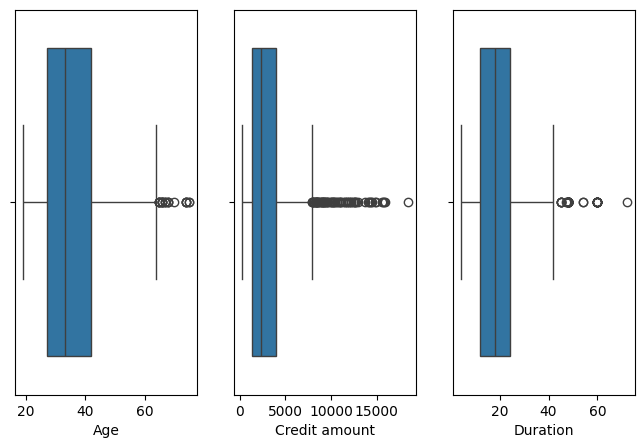

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = ['Age', 'Credit amount', 'Duration']
fig, axes = plt.subplots(1, 3, figsize=(8, 5))
for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
plt.show()

Negative Lower Bounds Interpretation: The lower bounds for Credit amount (-2,544.6) and Duration (-6.0) are mathematically negative due to the heavy right-skewness of the data. Since negative values are physically impossible in this context, it confirms that outliers exist exclusively on the higher end (extreme values).

Model Selection Strategy (Tree-Based Approach): With over 140 combined outliers in Credit amount and Duration (~14% of the dataset), distance-based models (e.g., Logistic Regression, KNN, SVM) would be heavily skewed. To mitigate this without losing critical financial risk data, robust tree-based algorithms like Random Forest or XGBoost must be prioritized.

Preserving Valuable Outliers: The 23 outliers in Age (above 64.5 years) represent a distinct and valuable demographic in credit risk assessment. These data points will be retained rather than removed, as tree-based models can effectively isolate and learn specific sub-rules for senior applicants.

In [7]:
def detect_outliers_iqr(data, column):
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
  return len(outliers) , lower_bound, upper_bound

for col in numerical_cols:
  outliers = detect_outliers_iqr(df, col)
  print(f"Number of outliers in {col}: {outliers[0]}")
  print(f"Lower bound: {outliers[1]}")
  print(f"Upper bound: {outliers[2]}")

Number of outliers in Age: 23
Lower bound: 4.5
Upper bound: 64.5
Number of outliers in Credit amount: 72
Lower bound: -2544.625
Upper bound: 7882.375
Number of outliers in Duration: 70
Lower bound: -6.0
Upper bound: 42.0


In [8]:
normal_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('binary', binary_transformer, binary_cols),
    ('categorical', categorical_transformer, categorical_cols),
    ('normal', normal_transformer, numerical_cols)
],remainder='drop')

### Best XGBoost Model Parameters

The `RandomizedSearchCV` process identified the following optimal hyperparameters for the `XGBoostClassifier`:

*   **`classifier__subsample`**: `1.0` - This means that the model will use 100% of the training data to grow each tree, indicating that subsampling rows was not found to be beneficial in this context.
*   **`classifier__n_estimators`**: `100` - The optimal number of boosting rounds (trees) is 100. This suggests that the model converges well within this number of trees and avoids overfitting.
*   **`classifier__max_depth`**: `4` - Each tree in the ensemble will have a maximum depth of 4. This is a relatively shallow tree depth, helping to prevent overfitting and keeping the model interpretable.
*   **`classifier__learning_rate`**: `0.2` - The step size shrinkage used in each boosting step to prevent overfitting. A learning rate of 0.2 indicates a moderately aggressive update strategy.
*   **`classifier__colsample_bytree`**: `0.9` - This indicates that 90% of the columns (features) will be randomly sampled for each tree. This helps in decorrelating the trees and improving robustness.

In [9]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

X = df.drop('Risk', axis=1)
y = df['Risk'].map({'good': 1, 'bad': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight = 0.30,
        random_state=random_state))
])

param_distributions = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 4, 5, 6, 7],
    'classifier__subsample': [0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)
best_xgb_model = xgb_search.best_estimator_
print(xgb_search.best_params_)
y_pred_xgb_opt = best_xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb_opt))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'classifier__subsample': 1.0, 'classifier__n_estimators': 100, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.2, 'classifier__colsample_bytree': 0.9}
              precision    recall  f1-score   support

           0       0.53      0.71      0.61        59
           1       0.86      0.74      0.79       141

    accuracy                           0.73       200
   macro avg       0.70      0.72      0.70       200
weighted avg       0.76      0.73      0.74       200



c:\Users\burak\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:38:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion Matrix:
Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.71      0.61        59
           1       0.86      0.74      0.79       141

    accuracy                           0.73       200
   macro avg       0.70      0.72      0.70       200
weighted avg       0.76      0.73      0.74       200



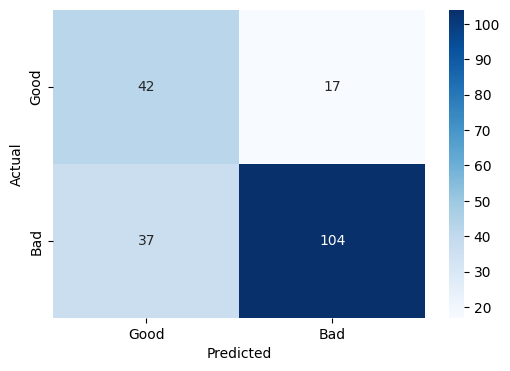

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb_opt)
print("Confusion Matrix:")
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
plt.xlabel('Predicted')
plt.ylabel('Actual')

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb_opt))